# Imports

In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import time
import tqdm
import math
import random

In [3]:
from sklearn.tree import DecisionTreeClassifier

In [4]:
from sklearn import tree

In [5]:
from collections import defaultdict

In [6]:
from dataclasses import dataclass

In [7]:
import ahocorasick

In [8]:
from statsmodels.stats.proportion import proportion_confint

In [9]:
import os
os.chdir('..')

In [10]:
from src.filtering_methods.filtering_base import FilteringExperiment, FilteringResults 

In [11]:
from src.filtering_methods.filtering_methods import NoneFilter, FilterEachIterXgboostPathSampleFinal, FilterDTSampleFinal

In [12]:
from src.dataset import Dataset

In [13]:
from src.sampling_methods.sampling_methods import RandomSample, XgboostSubsample, TreeSample, CostumeSample, sampling_utils

In [14]:
@dataclass
class FilteredGroup:
    key: str
    label: int
    size: int
    group: list

# Import Dataset and Preprocess

In [15]:
target_col = 'default_ind'

In [17]:
df = pd.read_csv('datasets/loan/data.csv')

/tmp/ipykernel_23728/3609998947.py:1: DtypeWarning: Columns (17,45,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('datasets/loan/data.csv')


## Get categorial columns

In [23]:
from pandas.api.types import is_numeric_dtype

In [24]:
from src.dataset import null_columns

In [25]:
categorial_columns = []
for c in df.columns:
    if not is_numeric_dtype(df[c]):
        categorial_columns.append(c)

In [27]:
coluns_to_drop = ['emp_title', 'issue_d', 'desc', 'title', 'earliest_cr_line', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d']
coluns_to_drop = coluns_to_drop + ['id']
categorial_columns = list(set(categorial_columns).difference(coluns_to_drop))

In [28]:
df = df.drop(columns=coluns_to_drop)

In [29]:
for c in categorial_columns:
    print(c)
    one_hot = pd.get_dummies(df[c], prefix=c)
    one_hot.columns = [c.replace(' ', '_').replace(',', '-').replace('<', '(').replace('>', ')') for c in one_hot.columns]
    df = df.join(one_hot).drop(columns=c)

term
initial_list_status
sub_grade
addr_state
pymnt_plan
zip_code
verification_status
home_ownership
verification_status_joint
purpose
grade
emp_length
application_type


In [30]:
df = null_columns(df)

## Train Test Split

In [31]:
from src.dataset import Dataset

In [32]:
from src.sampling_methods.sampling_methods import RandomSample, XgboostSubsample, TreeSample, CostumeSample, sampling_utils

In [244]:
df_sample = df.sample(n=55_000)

In [420]:
model_10 = xgb.XGBClassifier(n_jobs=12, n_estimators=10)

In [421]:
model_10.fit(df.drop(target_col, axis=1), df[target_col])

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=10, n_jobs=12, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

In [422]:
df_new = df[[target_col]]
df_new['pred'] = model_10.predict(df.drop(target_col, axis=1))

/tmp/ipykernel_23728/1119679137.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [419]:
model.predict_proba(df.sample(5, random_state=1).drop(target_col, axis=1))

array([[9.9998140e-01, 1.8614910e-05],
       [9.9953538e-01, 4.6464711e-04],
       [9.9807197e-01, 1.9280363e-03],
       [9.9734139e-01, 2.6586256e-03],
       [9.9965370e-01, 3.4628462e-04]], dtype=float32)

In [431]:
df_sample = df[df_new[target_col] == df_new['pred']].sample(200_000)

In [430]:
df[target_col].value_counts()

default_ind
0    809502
1     46467
Name: count, dtype: int64

In [428]:
df_sample[target_col].value_counts()

default_ind
0    809494
1     44073
Name: count, dtype: int64

In [432]:
X_train, X_test, y_train, y_test = train_test_split(df_sample.drop(target_col, axis=1), df_sample[target_col], test_size=0.2, shuffle = True)

In [433]:
dataset = Dataset(df, X_train, y_train, X_test, y_test, target_col, f1_score)

In [247]:
tree_filter = FilterDTSampleFinal('aya', examples_to_keep=15000, sample_percent=0.05, prediction_model=xgb.XGBClassifier(n_jobs=24))

In [248]:
tree_filter.test_filter_method(dataset, print_results=True)

FilteringResults(score=0.9764801297648013, filtered_score=0.9780666125101544, run_time=22.319430589675903, new_size_percent=0.4823409090909091)


## Create Coreset

In [434]:
from coretab.coreset_algorithms import CoreTabDT, CoreTabXGB

In [435]:
coretab_dt = CoreTabDT(examples_to_keep=10)

In [436]:
X_coreset, y_coreset = coretab_dt.create_coreset(X_train, y_train)

## Performace Gurantees

In [437]:
import plotly.express as px

In [1145]:
def print_precision_recall(coretab_dt):
    coretab_dt = pickle.load(open(f'{path_prefix}/gur_coretab.pkl', 'rb'))
    df_0, df_1 = coretab_dt.get_guarantees(X_test, y_test)
    df_vis = pd.concat([df_0.assign(metric='recall', delta_metric=df_0['delta_recall']),
                        df_1.assign(metric='precision', delta_metric=df_1['delta_precision'])])
    df_vis.rename(columns={'delta_metric': 'Performace Decrease', 'percent_remained': 'Coreset size'}, inplace=True)
    fig = px.line(df_vis, x='Coreset size', y='Performace Decrease', title='Metrics Decrease vs. Coreset size',
              hover_data='group_id', color='metric', markers=True)
    fig.show()

## Explore the effect of features on the coreset

### Find feature leaves

In [446]:
def get_rules_for_leaf(tree, node_to_search, node_id=0, feature_names=X_train.columns):
    """
    Recursively traverse the decision tree to extract rules leading to a specific leaf node.
    
    Parameters:
    tree (sklearn.tree._tree.Tree): The trained decision tree object.
    node_id (int): The node ID to start traversal (typically the root node ID).
    feature_names (list): List of feature names.
    threshold_sign (list): List of threshold signs ('<=', '>') for each node.
    
    Returns:
    list: List of rule strings leading to the specified leaf node.
    """
    # Initialize an empty list to store the rules
    rules = []

    # Check if the current node is a leaf node
    if tree.children_left[node_id] == -1 and tree.children_right[node_id] == -1:
        # Return the list of rules when reaching a leaf node
        return rules, node_id == node_to_search
    
    # Get the feature index and threshold value for the current node
    feature_index = tree.feature[node_id]
    threshold = tree.threshold[node_id]
    
    # Get the feature name and threshold sign ('<=', '>')
    feature_name = feature_names[feature_index]
    
    # Recursively traverse the left and right child nodes
    left_rules, is_node_there_left = get_rules_for_leaf(tree, node_to_search, tree.children_left[node_id], feature_names)
    right_rules, is_node_there_right = get_rules_for_leaf(tree, node_to_search, tree.children_right[node_id], feature_names)
    
    # Append the rules from left and right subtrees
    if is_node_there_left:
        rules.extend([f"{feature_name} <= {threshold:.2f}"] + left_rules)
    if is_node_there_right:
        rules.extend([f"{feature_name} >= {threshold:.2f}"] + right_rules)
    
    return rules, is_node_there_left or is_node_there_right

In [447]:
def search_for_leaves_with_feature(coretab_dt: CoreTabDT, feature_name):
    relevant_nodes = []
    for node_id in df_0['group_id'].values:
        node_description = get_rules_for_leaf(coretab_dt.model.tree_, node_id)[0]
        if any([s.startswith(feature_name + ' ') for s in node_description]):
            relevant_nodes.append(node_id)
    return relevant_nodes

In [448]:
leaves_with_feature = search_for_leaves_with_feature(coretab_dt, 'member_id')

### Visualize feature Tree

In [452]:
from copy import deepcopy

In [453]:
from sklearn.tree._tree import Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [454]:
# Define a function to extract a subset of nodes (e.g., based on depth)
def extract_subset_tree(tree, hom_node_indexes, node_index=0):

    is_hom_leaf = True if node_index in hom_node_indexes else False
    
    if node_index <= -1:
        return [], [], is_hom_leaf

    left_child = tree.children_left[node_index]
    right_child = tree.children_right[node_index]

    # Recursive traversal to extract subset
    nodes = [node_index]
    edges = []

    is_hom_leaf_left = False
    if left_child >= -1:
        left_nodes, left_edges, is_hom_leaf_left = extract_subset_tree(tree, hom_node_indexes, left_child)
        if is_hom_leaf_left:
            nodes.extend(left_nodes)
            edges.extend([(node_index, left_child, 'left')])
            edges.extend([(node_index, right_child, 'right')])
            edges.extend(left_edges)
            

    is_hom_leaf_right = False
    if right_child >= -1:
        right_nodes, right_edges, is_hom_leaf_right = extract_subset_tree(tree, hom_node_indexes, right_child)
        if is_hom_leaf_right:
            nodes.extend(right_nodes)
            edges.extend([(node_index, right_child, 'right')])
            edges.extend([(node_index, left_child, 'left')])
            edges.extend(right_edges)

    return nodes, edges, (is_hom_leaf or is_hom_leaf_right or is_hom_leaf_left)

In [455]:
class TreeAttributeAccessor:
    def __init__(self, tree, edges):
        """
        Initialize the TreeAttributeAccessor with a sklearn.tree._tree.Tree object.
        
        Parameters:
        tree (sklearn.tree._tree.Tree): The decision tree object (from sklearn.tree).
        """
        self.tree = tree
        self.left_childs = np.array([val if (node_id, val, 'left') in edges else -1 for node_id, val in enumerate(tree.children_left)])
        self.right_childs = np.array([val if (node_id, val, 'right') in edges else -1 for node_id, val in enumerate(tree.children_right)])

        
    def __getattr__(self, attr):
        """
        Override the __getattr__ method to fetch attributes from the underlying Tree object.
        
        Parameters:
        attr (str): Name of the attribute to fetch.
        
        Returns:
        Any: Value of the specified attribute from the underlying Tree object.
        """
        if hasattr(self.tree, attr):
            if attr == 'children_left':
                return self.left_childs
            elif attr == 'children_right':
                return self.right_childs
            return getattr(self.tree, attr)
        else:
            raise AttributeError(f"'{type(self.tree).__name__}' object has no attribute '{attr}'")


In [1004]:
def plot_path_to_leaves(coretab_dt: CoreTabDT, leaves=None, show_fig=True, columns=X_train.columns):
    if leaves is None:
        leaves = list(coretab_dt.hom_groups.keys())

    nodes, edges, _ = extract_subset_tree(coretab_dt.model.tree_, leaves)
    new_t = TreeAttributeAccessor(coretab_dt.model.tree_, edges)
    coretab_dt_copy = deepcopy(coretab_dt)
    coretab_dt_copy.model.tree_ = new_t
    plt.figure(figsize=(20,10))  # Adjust the figure size as needed
    plot_tree(coretab_dt_copy.model, filled=True, feature_names=columns,
              impurity=False, max_depth=12, node_ids=True)
    if show_fig:
        plt.show()
    

def plot_feature_filter_tree(coretab_dt, feature, show_fig=True):
    leaves_with_feature = search_for_leaves_with_feature(coretab_dt, feature)
    plot_path_to_leaves(coretab_dt, leaves_with_feature, show_fig=False)
    # Get the current axes to access the tree plot elements
    if show_fig:
        plt.show()

### Guarantees without feature

In [464]:
def coretab_object_without_leaves(coretab_dt: CoreTabDT, leaves_to_remove: list):
    coretab_copy = deepcopy(coretab_dt)
    coretab_copy.hom_groups_candidates = [c for c in coretab_copy.hom_groups_candidates if not c.key in leaves_to_remove]
    coretab_copy.hom_groups = dict()
    coretab_copy.choose_groups(y_train)
    return coretab_copy.get_guarantees(X_test, y_test)

def coretab_gurantees_without_feature(coretab_dt: CoreTabDT, feature_to_remove):
    leaves_with_feature = search_for_leaves_with_feature(coretab_dt, feature_to_remove)
    df0_new, df1_new = coretab_object_without_leaves(coretab_dt, leaves_with_feature)
    return df0_new, df1_new

### Visualize feature Tree

In [169]:
from sklearn.tree._tree import Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [170]:
# Define a function to extract a subset of nodes (e.g., based on depth)
def extract_subset_tree(tree, hom_node_indexes, node_index=0):

    is_hom_leaf = True if node_index in hom_node_indexes else False
    
    if node_index <= -1:
        return [], [], is_hom_leaf

    left_child = tree.children_left[node_index]
    right_child = tree.children_right[node_index]

    # Recursive traversal to extract subset
    nodes = [node_index]
    edges = []

    is_hom_leaf_left = False
    if left_child >= -1:
        left_nodes, left_edges, is_hom_leaf_left = extract_subset_tree(tree, hom_node_indexes, left_child)
        if is_hom_leaf_left:
            nodes.extend(left_nodes)
            edges.extend([(node_index, left_child, 'left')])
            edges.extend([(node_index, right_child, 'right')])
            edges.extend(left_edges)
            

    is_hom_leaf_right = False
    if right_child >= -1:
        right_nodes, right_edges, is_hom_leaf_right = extract_subset_tree(tree, hom_node_indexes, right_child)
        if is_hom_leaf_right:
            nodes.extend(right_nodes)
            edges.extend([(node_index, right_child, 'right')])
            edges.extend([(node_index, left_child, 'left')])
            edges.extend(right_edges)

    return nodes, edges, (is_hom_leaf or is_hom_leaf_right or is_hom_leaf_left)

In [89]:
class TreeAttributeAccessor:
    def __init__(self, tree, edges):
        """
        Initialize the TreeAttributeAccessor with a sklearn.tree._tree.Tree object.
        
        Parameters:
        tree (sklearn.tree._tree.Tree): The decision tree object (from sklearn.tree).
        """
        self.tree = tree
        self.left_childs = np.array([val if (node_id, val, 'left') in edges else -1 for node_id, val in enumerate(tree.children_left)])
        self.right_childs = np.array([val if (node_id, val, 'right') in edges else -1 for node_id, val in enumerate(tree.children_right)])

        
    def __getattr__(self, attr):
        """
        Override the __getattr__ method to fetch attributes from the underlying Tree object.
        
        Parameters:
        attr (str): Name of the attribute to fetch.
        
        Returns:
        Any: Value of the specified attribute from the underlying Tree object.
        """
        if hasattr(self.tree, attr):
            if attr == 'children_left':
                return self.left_childs
            elif attr == 'children_right':
                return self.right_childs
            return getattr(self.tree, attr)
        else:
            raise AttributeError(f"'{type(self.tree).__name__}' object has no attribute '{attr}'")


In [187]:
def plot_path_to_leaves(coretab_dt: CoreTabDT, leaves=None, show_fig=True):
    if leaves is None:
        leaves = list(coretab_dt.hom_groups.keys())

    nodes, edges, _ = extract_subset_tree(coretab_dt.model.tree_, leaves)
    new_t = TreeAttributeAccessor(coretab_dt.model.tree_, edges)
    coretab_dt_copy = deepcopy(coretab_dt)
    coretab_dt_copy.model.tree_ = new_t
    plt.figure(figsize=(20,10))  # Adjust the figure size as needed
    plot_tree(coretab_dt_copy.model, filled=True, feature_names=tree_filter.X_train_filtered.drop(columns='id').columns,
              impurity=False, max_depth=12, node_ids=True)
    if show_fig:
        plt.show()
    

def plot_feature_filter_tree(coretab_dt, feature):
    leaves_with_feature = search_for_leaves_with_feature(coretab_dt, feature)
    plot_path_to_leaves(coretab_dt, leaves_with_feature, show_fig=False)
    # Get the current axes to access the tree plot elements
    plt.show()

In [330]:
new_t = TreeAttributeAccessor(dtree, edges)

In [331]:
tree_filter.model.tree_ = new_t

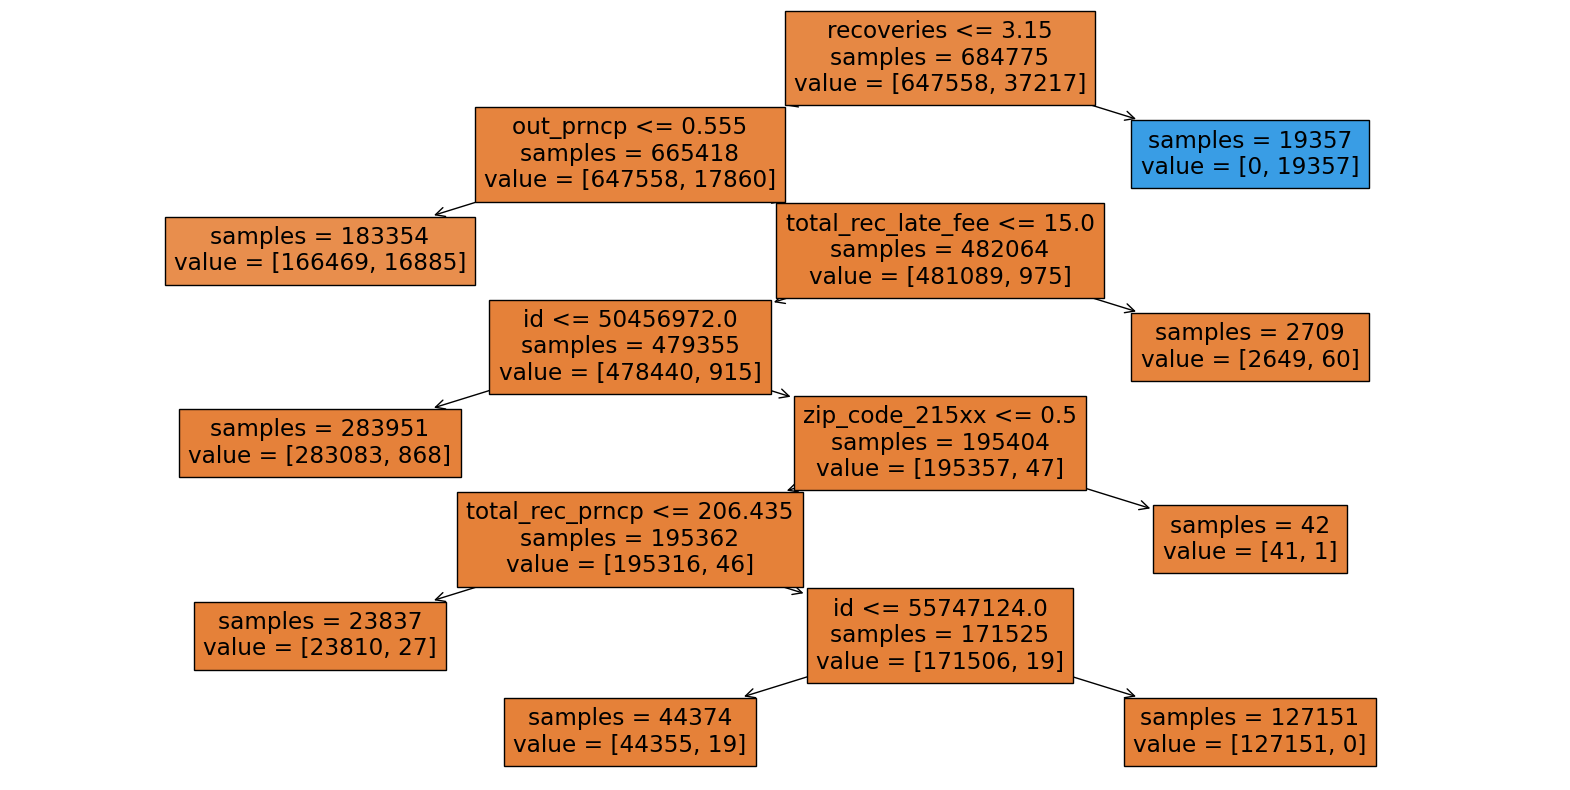

<Figure size 640x480 with 0 Axes>

In [332]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))  # Adjust the figure size as needed
plot_tree(tree_filter.model, filled=True, feature_names=tree_filter.X_train_filtered.columns, max_depth=7, impurity=False)
plt.show()
plt.savefig('small_tree_demo', dpi=1000, format='png')

## Button on tree

In [168]:
def compare_gurantees_without_leaves(coretab_dt: CoreTabDT, leaves_to_remove: list, only_recall=True):
    df0, df1 = coretab_dt.get_guarantees(X_test, y_test)
    df0_new, df1_new = coretab_object_without_leaves(coretab_dt, leaves_to_remove)
    
    df_vis = pd.concat([df_0.assign(df_data='all_data'), df0_new.assign(df_data='without_groups')])
    df_vis.rename(columns={'delta_recall': 'Delta Recall', 'percent_remained': 'Coreset size'}, inplace=True)
    
    fig = px.line(df_vis, x='Coreset size', y='Delta Recall', title='Recall vs. Coreset size', hover_data='group_id', color='df_data', markers=True)
    fig.update_layout(
        autosize=False,
        width=700,
        height=400,
        font={'size': 18}
    )
    fig.show()

In [617]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [1140]:
def compare_gurantees_without_feature(coretab_dt: CoreTabDT, feature, real_feautre='member_id'):
    coretab_dt = pickle.load(open(f'{path_prefix}/gur_coretab.pkl', 'rb'))
    
    df0, df1 = coretab_dt.get_guarantees(X_test, y_test)
    df0_new, df1_new = coretab_gurantees_without_feature(coretab_dt, real_feautre)
    
    df_vis = pd.concat([df_0.assign(df_data='all_data'), df0_new.assign(df_data='without_feature')])
    df_vis.rename(columns={'delta_recall': 'Delta Recall', 'percent_remained': 'Coreset size'}, inplace=True)

    df_vis_1 = pd.concat([df_1.assign(df_data='all_data'), df1_new.assign(df_data='without_feature')])
    df_vis_1.rename(columns={'delta_precision': 'Delta Precision', 'percent_remained': 'Coreset size'}, inplace=True)

    fig = make_subplots(rows=1, cols=2, subplot_titles=('Recall vs. Coreset size (Negative Data Reduction)', 'Precision vs. Coreset size (Positive Data Reduction)'))
    
    fig1 = px.line(df_vis, x='Coreset size', y='Delta Recall', title='Recall vs. Coreset size', hover_data='group_id', color='df_data', markers=True)
    fig2 = px.line(df_vis_1, x='Coreset size', y='Delta Precision', title='Precision vs. Coreset size', hover_data='group_id', color='df_data', markers=True)
    
    for trace in fig1['data']:
        fig.add_trace(trace, row=1, col=1)

    # Add the second plotly express figure to the second subplot without showing the legend
    for trace in fig2['data']:
        fig.add_trace(go.Scatter(trace, showlegend=False), row=1, col=2)
    
    
    fig.show()

In [1143]:
def compare_gurantees_without_nodes(coretab_dt: CoreTabDT, feature, real_feautre='annual_inc'):
    coretab_dt = pickle.load(open(f'{path_prefix}/gur_coretab.pkl', 'rb'))
    
    df0, df1 = coretab_dt.get_guarantees(X_test, y_test)
    df0_new, df1_new = coretab_gurantees_without_feature(coretab_dt, real_feautre)
    
    df_vis = pd.concat([df_0.assign(df_data='all_data'), df0_new.assign(df_data='without_feature')])
    df_vis.rename(columns={'delta_recall': 'Delta Recall', 'percent_remained': 'Coreset size'}, inplace=True)

    df_vis_1 = pd.concat([df_1.assign(df_data='all_data'), df1_new.assign(df_data='without_feature')])
    df_vis_1.rename(columns={'delta_precision': 'Delta Precision', 'percent_remained': 'Coreset size'}, inplace=True)

    fig = make_subplots(rows=1, cols=2, subplot_titles=('Recall vs. Coreset size (Negative Data Reduction)', 'Precision vs. Coreset size (Positive Data Reduction)'))
    
    fig1 = px.line(df_vis, x='Coreset size', y='Delta Recall', title='Recall vs. Coreset size', hover_data='group_id', color='df_data', markers=True)
    fig2 = px.line(df_vis_1, x='Coreset size', y='Delta Precision', title='Precision vs. Coreset size', hover_data='group_id', color='df_data', markers=True)
    
    for trace in fig1['data']:
        fig.add_trace(trace, row=1, col=1)

    # Add the second plotly express figure to the second subplot without showing the legend
    for trace in fig2['data']:
        fig.add_trace(go.Scatter(trace, showlegend=False), row=1, col=2)
    
    
    fig.show()

In [1144]:
compare_gurantees_without_nodes(coretab_dt, 'annual_inc')

In [1099]:
compare_gurantees_without_feature(coretab_dt, 'annual_inc')

## Interactive Coreset

In [77]:
import ipywidgets as widgets
from IPython.display import display

# Create the text input widget
text_input = widgets.Text(
    description='Node ids:',
    value='feature name/ node_id1,node_id2'
)

# Create the button widget
button = widgets.Button(
    description='Add nodes to coreset'
)

# Define what happens when the button is clicked
def on_button_clicked(b):
    node_ids_regex = all(char.isdigit() or char in ', ' for char in text_input.value)
    if node_ids_regex:
        leaves = [int(s.strip()) for s in text_input.value.replace(']', '').replace('[', '').split(',')]
        compare_gurantees_without_leaves(coretab_dt, leaves)
    else:
        compare_gurantees_without_feature(coretab_dt, text_input.value)
# Link the button to the callback function
button.on_click(on_button_clicked)

# Display the widgetcontains_number = any(char.isdigit() for char in trimmed_string)
display(text_input, button)

Text(value='feature name/ node_id1,node_id2', description='Node ids:')

Button(description='Add nodes to coreset', style=ButtonStyle())

In [566]:
display_coretab_dt = deepcopy(coretab_dt)

In [1132]:
def display_coreset_without_feature(coretab_dt, feature_name):
    coretab_dt_no_zip_code = pickle.load(open(f'{path_prefix}/coretab_dt_no_zip_code.pkl', 'rb'))
    highlight_no_zip = [coretab_dt_no_zip_code.hom_groups_candidates[i].key for i in range(30)]
    plot_path_to_leaves(coretab_dt_no_zip_code, np.array(highlight_no_zip)[[0,1,2,3,4,5]], show_fig=False, columns=[c for c in X_train.columns if not c.startswith('zip')])
    gray_range = [i for i in range(15, 76)]
    gray_range = []
    green_range = [i for i in range(171, 200)] + [i for i in range(145, 148)] + [i for i in range(53, 56)]
    ax = plt.gca()
    
    loc_dict = {
        175: (0.705, 0.32),
        146: (0.445, 0.12),
        218: (0.651, 0.82),
        12: (0.054, 0.418),
        54: (0.227, 0.02),
        179: (0.662, 0.02)
    }
    
    # Iterate over each node in the tree plot
    for node in ax.get_children():
        if hasattr(node, 'get_text') and node.get_text().startswith('node '):
            node_id = int(node.get_text().split()[1][1:])  # Extract the node ID from the text
            node.set_text(node.get_text().replace('value = ', 'label count='))
        # Highlight the node if it's in the list of nodes to highlight
            if node.get_text().count('\n') == 2:
                node.set_text('\n'.join([node.get_text().split('\n')[0], 'leaf node - no condition'] +  node.get_text().split('\n')[1:]))
            sizes = eval(node.get_text()[node.get_text().find('['): ])
            if sizes[0] > sizes[1]:
                if sizes[1] == 0:
                    node.set_backgroundcolor('tomato')
                elif sizes[0] / sizes[1] >= 10:
                    node.set_backgroundcolor('salmon')
                else:
                    node.set_backgroundcolor('lightsalmon')
            if node_id in gray_range:
                node.set_backgroundcolor('gray')  # Change node color to highlight
            # if node_id in highlight_nodes[:20]:
            #     node.set_backgroundcolor('coral')
            if node_id in green_range:
                node.set_backgroundcolor('lime')
                #node.get_edgecolor('red')
            if node_id in gray_range:
                node.set_backgroundcolor('gray')
        
            if node_id in loc_dict.keys():
                #corners = node.get_window_extent().transformed(ax.transFigure.inverted()).bounds
                #print(corners)
                rect = patches.Rectangle(loc_dict[node_id], 0.068, 0.063, linewidth=4, edgecolor='purple', facecolor='none', visible=True, zorder=1000000)
                ax.add_patch(rect)
            # if node = 151
            check_node = node 
        # else:
        #     node.set_edgecolor('b')
    # plt.savefig('tree_for_demo.pdf', dpi=1000, format='pdf')
    # plt.show()

In [1133]:
def display_coreset(coretab_dt):
    display_coretab_dt = pickle.load(open(f'{path_prefix}/display_coretab_dt.pkl', 'rb'))
    highlight_nodes = [display_coretab_dt.hom_groups_candidates[i].key for i in range(30)]
    plot_path_to_leaves(display_coretab_dt, np.array(highlight_nodes)[[0,1,2,3,4]], show_fig=False)
    gray_range = []
    green_range = []
    ax = plt.gca()


    loc_dict = {
        178: (0.5737, 0.107),
        150: (0.443, 0.197),
        208: (0.65, 0.834),
        67: (0.183, 0.015),
        12: (0.052, 0.472),
    }
    
    # Iterate over each node in the tree plot
    for node in ax.get_children():
        if hasattr(node, 'get_text') and node.get_text().startswith('node '):
            node_id = int(node.get_text().split()[1][1:])  # Extract the node ID from the text
            node.set_text(node.get_text().replace('value = ', 'label count='))
        # Highlight the node if it's in the list of nodes to highlight
            if node.get_text().count('\n') == 2:
                node.set_text('\n'.join([node.get_text().split('\n')[0], 'leaf node - no condition'] +  node.get_text().split('\n')[1:]))
            sizes = eval(node.get_text()[node.get_text().find('['): ])
            if sizes[0] > sizes[1]:
                if sizes[1] == 0:
                    node.set_backgroundcolor('tomato')
                elif sizes[0] / sizes[1] >= 10:
                    node.set_backgroundcolor('salmon')
                else:
                    node.set_backgroundcolor('lightsalmon')
            if node_id in gray_range:
                node.set_backgroundcolor('gray')  # Change node color to highlight
            # if node_id in highlight_nodes[:20]:
            #     node.set_backgroundcolor('coral')
            if node_id in green_range:
                node.set_backgroundcolor('lime')
                #node.get_edgecolor('red')
            if node_id in gray_range:
                node.set_backgroundcolor('gray')
            
            if node_id in loc_dict.keys():
                #corners = node.get_window_extent().transformed(ax.transFigure.inverted()).bounds
                #print(corners)
                rect = patches.Rectangle(loc_dict[node_id], 0.07, 0.061, linewidth=4, edgecolor='purple', facecolor='none', visible=True, zorder=1000)
                ax.add_patch(rect)
            # if node = 151
            check_node = node 
        # else:
        #     node.set_edgecolor('b')
    # plt.savefig('tree_for_demo.pdf', dpi=1000, format='pdf')
    # plt.show()

In [1134]:
def display_coreset_without_node(coretab_dt, node_id):
    display_coretab_dt = pickle.load(open(f'{path_prefix}/display_coretab_dt.pkl', 'rb'))
    highlight_nodes = [display_coretab_dt.hom_groups_candidates[i].key for i in range(30)]
    plot_path_to_leaves(display_coretab_dt, np.array(highlight_nodes)[[0,1,2,3,4,5,9]], show_fig=False)
    gray_range = [i for i in range(15, 76)]
    gray_range = [67]
    green_range = [179, 180, 4, 10]
    ax = plt.gca()

    loc_dict = {
        178: (0.623, 0.111),
        150: (0.508, 0.201),
        208: (0.681, 0.838),
        12: (0.1617, 0.4742),
        10: (0.086, 0.4742),
        180: (0.662, 0.02)
}
    
    # Iterate over each node in the tree plot
    for node in ax.get_children():
        if hasattr(node, 'get_text') and node.get_text().startswith('node '):
            node_id = int(node.get_text().split()[1][1:])  # Extract the node ID from the text
        # Highlight the node if it's in the list of nodes to highlight
            node.set_text(node.get_text().replace('value = ', 'label count='))
            if node.get_text().count('\n') == 2:
                node.set_text('\n'.join([node.get_text().split('\n')[0], 'leaf node - no condition'] +  node.get_text().split('\n')[1:]))
            sizes = eval(node.get_text()[node.get_text().find('['): ])
            if sizes[0] > sizes[1]:
                if sizes[1] == 0:
                    node.set_backgroundcolor('tomato')
                elif sizes[0] / sizes[1] >= 10:
                    node.set_backgroundcolor('salmon')
                else:
                    node.set_backgroundcolor('lightsalmon')
            if node_id in gray_range:
                node.set_backgroundcolor('gray')  # Change node color to highlight
            # if node_id in highlight_nodes[:20]:
            #     node.set_backgroundcolor('coral')
            if node_id in green_range:
                node.set_backgroundcolor('lime')
                #node.get_edgecolor('red')
            if node_id in gray_range:
                node.set_backgroundcolor('gray')
        
            if node_id in loc_dict.keys():
                #corners = node.get_window_extent().transformed(ax.transFigure.inverted()).bounds
                #print(corners)
                rect = patches.Rectangle(loc_dict[node_id], 0.06, 0.05, linewidth=4, edgecolor='purple', facecolor='none', visible=True, zorder=1000000)
                ax.add_patch(rect)
            # if node = 151
            check_node = node 
        # else:
        #     node.set_edgecolor('b')
    # plt.savefig('tree_for_demo.pdf', dpi=1000, format='pdf')
    # plt.show()

In [974]:
import pickle

In [975]:
path_prefix = 'results/demo/'
def write_object(obj, filename):
    with open(f'{path_prefix}{filename}.pkl', 'wb') as f:
        pickle.dump(obj, f)

In [1139]:
write_object(coretab_dt, 'gur_coretab')

In [981]:
easy_coretab = pickle.load(open(f'{path_prefix}/easy_coretab_dt.pkl', 'rb'))

# Coretab Demonstration

## Coretab Introduction

In [982]:
from coretab.coreset_algorithms import CoreTabDT, CoreTabXGB

In [983]:
coretab_dt = CoreTabDT(examples_to_keep=100)

In [984]:
X_coreset, y_coreset = coretab_dt.create_coreset(X_train, y_train)

In [1146]:
print_precision_recall(coretab_dt)

## Examine Created Coreset
1. coreset.display() -> show tree (reduced datamap)
2. Explain the tree - what every node means, where can you see the split, where can you see the labels distribution (using the colors), what are the coreset regions.
3. The analyst would like to examine that there are not protected groups that are exluded from the coreset)

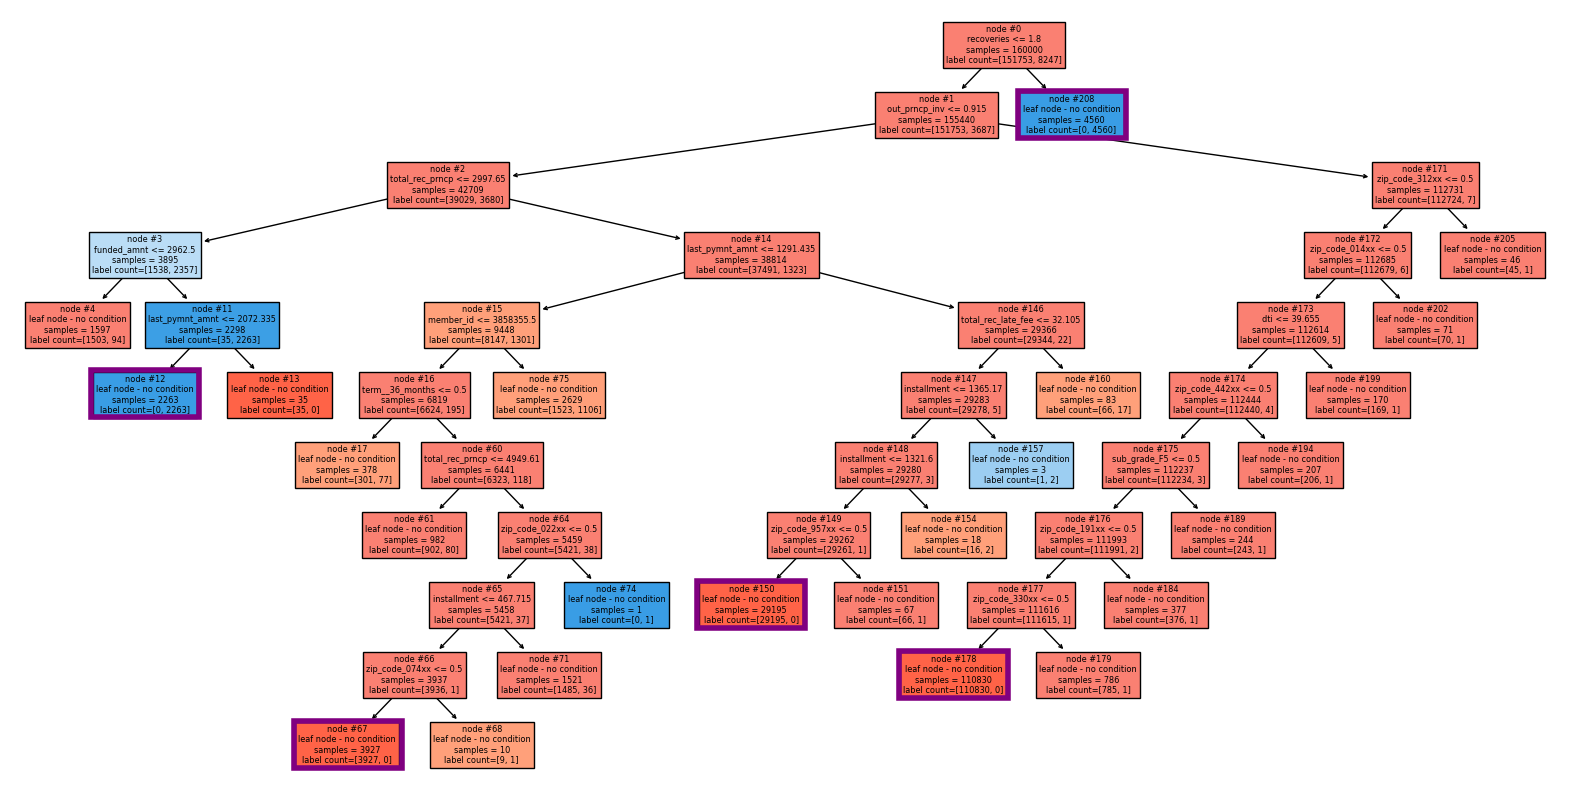

In [1135]:
display_coreset(coretab_dt)

## Explore the implications of choosing protected group
1. Show performance with and without groups (interactive from the previous tree)

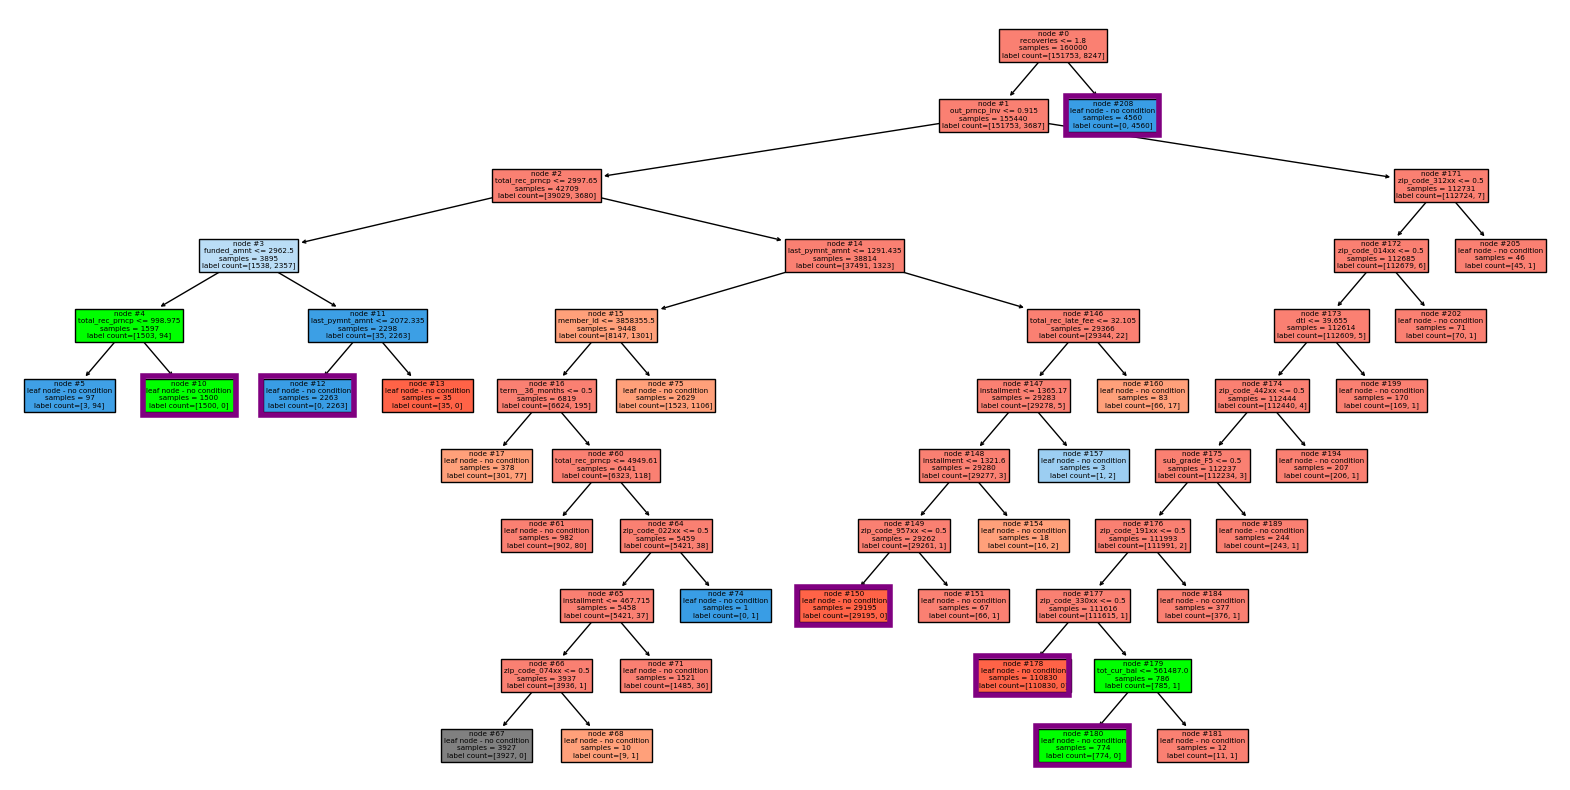

In [1136]:
display_coreset_without_node(coretab_dt, 67)

In [994]:
compare_gurantees_without_nodes(coretab_dt, 67)

### Button

In [ ]:
from IPython.display import display,clear_output


In [961]:
%matplotlib inline

In [965]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('inline')


# Create a text box widget
text_box = widgets.Text(
    value='1',
    placeholder='Enter a number',
    description='Size:',
    disabled=False
)

# Create a button widget
button = widgets.Button(
    description='Plot Rectangle',
    disabled=False,
    button_style='',
    tooltip='Click to plot rectangle',
    icon='check'
)

out = widgets.Output()


# Define the function to plot the rectangle
def plot_rectangle(size):
    size = float(size)
    fig, ax = plt.subplots()
    rect = plt.Rectangle((0.5 - size/2, 0.5 - size/2), size, size, fill=True, edgecolor='r', facecolor='blue', alpha=0.5)
    ax.add_patch(rect)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal', adjustable='box')
    with out:
        clear_output(wait=True)
        display(ax.figure)

# Define the button click event handler
def on_button_click(b):
    clear_output(wait=True)
    display(text_box, button)
    plot_rectangle(text_box.value)

# Attach the click event handler to the button
button.on_click(on_button_click)

# Display the widgets
display(text_box, button)


ValueError: 'inline' is not a valid value for backend; supported values are ['GTK3Agg', 'GTK3Cairo', 'GTK4Agg', 'GTK4Cairo', 'MacOSX', 'nbAgg', 'QtAgg', 'QtCairo', 'Qt5Agg', 'Qt5Cairo', 'TkAgg', 'TkCairo', 'WebAgg', 'WX', 'WXAgg', 'WXCairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template']

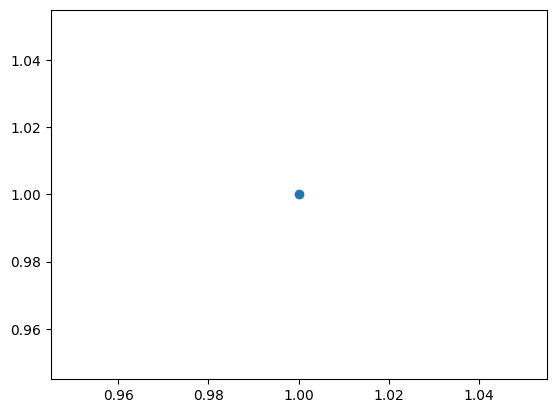

<Figure size 640x480 with 0 Axes>

In [964]:
import matplotlib.pyplot as plt
x = [1];
y = [1];

def onclick(event):
    if event.button == 1:
         x.append(event.xdata)
         y.append(event.ydata)
    #clear frame
    plt.clf()
    plt.scatter(x,y); #inform matplotlib of the new data
    plt.draw() #redraw

fig,ax=plt.subplots()
ax.scatter(x,y)
fig.canvas.mpl_connect('button_press_event',onclick)
plt.show()
plt.draw()

In [963]:
node.set_bounds()

ValueError: not enough values to unpack (expected 4, got 0)

In [504]:
check_node.get_text()

'node #208\nsamples = 4560\nvalue = [0, 4560]'

In [508]:
check_node.get_position()

(1102.8846153846152, 665.0)

In [517]:
'\n'.join([check_node.get_text().split('\n')[0], 'leaf node - no condition'] +  check_node.get_text().split('\n')[1:])

'node #208\nleaf node - no condition\nsamples = 4560\nvalue = [0, 4560]\n                                     '

In [535]:
sizes = eval(check_node.get_text()[check_node.get_text().find('['): ])

In [536]:
if sizes[0] > sizes[1]:
    if sizes[0] / sizes[1] >= 10:
        check_node.set_backgroundcolor('salmon')
    else:
        check_node.set_backgroundcolor('lightsalmon')

In [512]:
if check_node.get_text().count('\n') == 2:
    check_node.set_text(check_node.get_text() + '\n                  ')

In [510]:
check_node.set_text()

'node #208\nsamples = 4560\nvalue = [0, 4560]'

In [ ]:
check_node.set_backgroundcolor()

In [509]:
type(check_node)

matplotlib.text.Annotation

## Explore the Effect of a specific column
1. Performance with and without it - Don't consider the datamap regions that use this column in the creation of the datamap.
2. Tree of the specific column

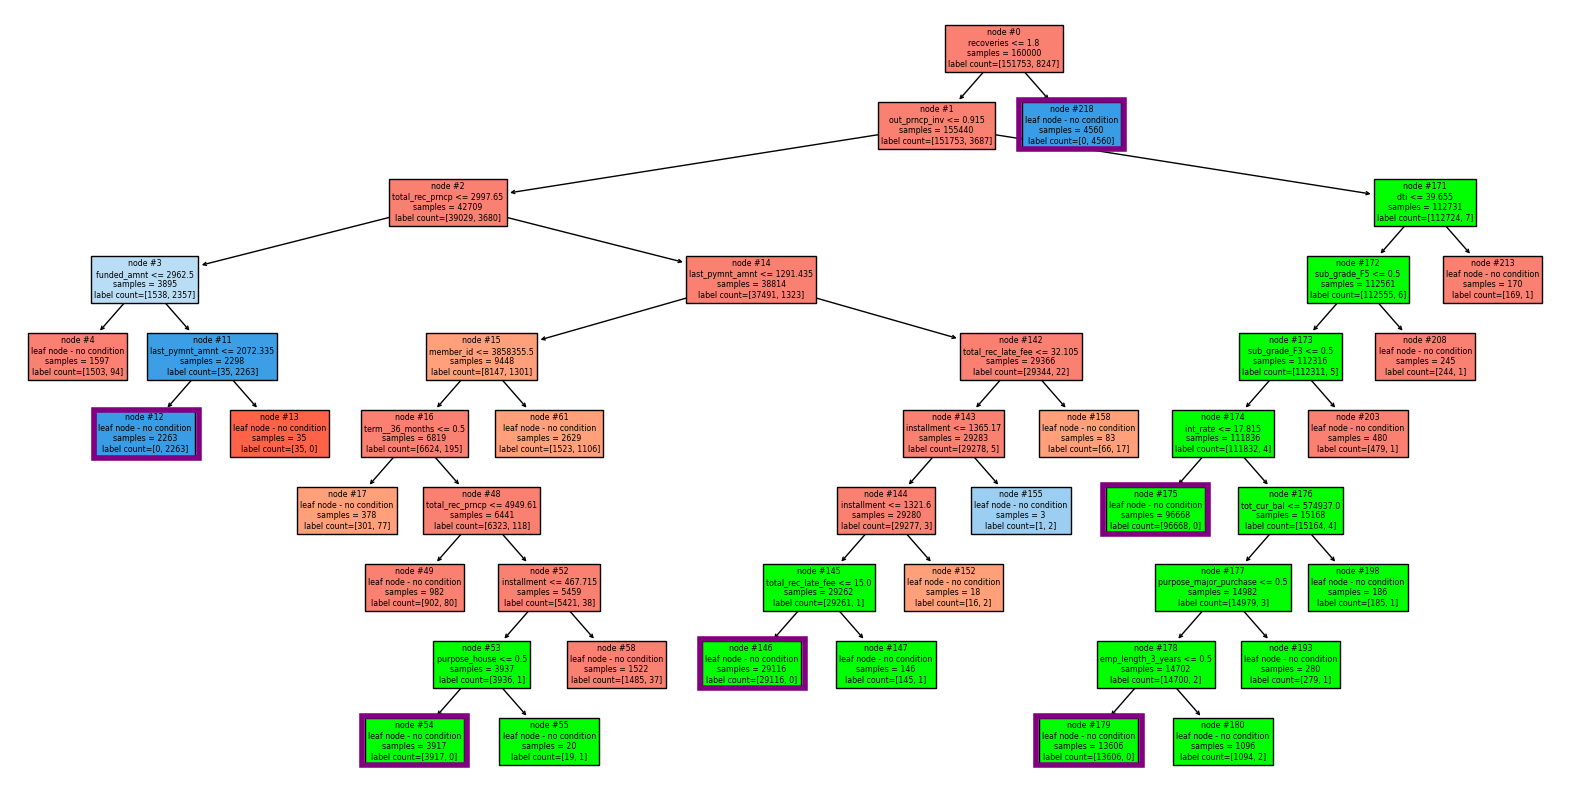

In [1138]:
display_coreset_without_feature(coretab_dt, 'zip_code')

In [1102]:
compare_gurantees_without_feature(coretab_dt, 'zip_code')

# Tova notes
1. seperate each scenario - start with what will be examined, end with conclution.
2. script for the demo: introduction to corsets - written in notebook (Welcome to coretab 20 sec), coretab use, scenarioes 
4. Graph changes - change colors - pos, neg, size coralate to number of samples / same size for all nodes 